# Nonlinear Relationship & Variable Transformation Analysis

Using the following data with $x$ as the independent variable and $y$ as the dependent variable:

| $x$ | -8 | -16 | 12 | 2 | 18 |
| :--- | :---: | :---: | :---: | :---: | :---: |
| $y$ | 58 | 247 | 153 | 3 | 341 |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "x": [-8, -16, 12, 2, 18],
    "y": [58, 247, 153, 3, 341]
})
df

,x,y
0,-8,58
1,-16,247
2,12,153
3,2,3
4,18,341


## a. Create a scatter diagram and describe the relationship between x and y.

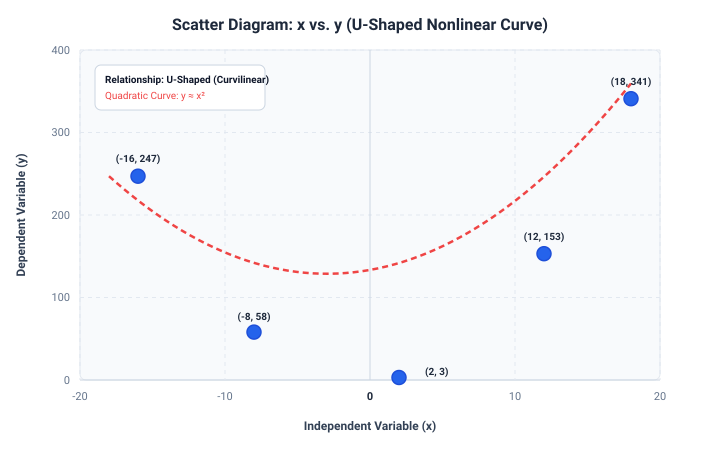

In [2]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(df["x"], df["y"], color="#2563eb", s=90, zorder=3, edgecolors="#1d4ed8", linewidths=1.5)

# Annotate points
for _, row in df.iterrows():
    ax.annotate(f"({row['x']}, {row['y']})", (row["x"], row["y"]), textcoords="offset points", xytext=(0, 9), ha="center", fontsize=9, weight="bold")

# Plot fitted parabolic curve y ≈ x^2
x_curve = np.linspace(-18, 20, 100)
p = np.polyfit(df["x"], df["y"], 2)
ax.plot(x_curve, np.polyval(p, x_curve), color="#ef4444", linestyle="--", linewidth=2, label="Quadratic fit: y ≈ x²")

ax.set_title("Scatter Diagram: x vs. y (U-Shaped Nonlinear Curve)", fontsize=12, pad=10, fontweight="bold")
ax.set_xlabel("Independent Variable (x)", fontsize=11)
ax.set_ylabel("Dependent Variable (y)", fontsize=11)
ax.axvline(0, color="#94a3b8", linestyle=":", alpha=0.7)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Description of Relationship between $x$ and $y$:**
- The relationship between $x$ and $y$ is **nonlinear / curvilinear (U-shaped)**.
- For negative values of $x$, as $x$ increases toward 0, $y$ decreases rapidly.
- For positive values of $x$, as $x$ increases away from 0, $y$ increases rapidly.
- Notice that each $y$ value is approximately equal to $x^2$ (e.g., $(-16)^2 = 256 \approx 247$, $(-8)^2 = 64 \approx 58$, $2^2 = 4 \approx 3$, $12^2 = 144 \approx 153$, $18^2 = 324 \approx 341$).

## b. Compute the correlation coefficient between x and y.

### Step-by-Step Calculation Table

Sample size $n = 5$:
- $\bar{x} = \frac{-8 - 16 + 12 + 2 + 18}{5} = \frac{8}{5} = 1.6$
- $\bar{y} = \frac{58 + 247 + 153 + 3 + 341}{5} = \frac{802}{5} = 160.4$

| Point | $x$ | $y$ | $x - \bar{x}$ | $(x - \bar{x})^2$ | $y - \bar{y}$ | $(y - \bar{y})^2$ | $(x - \bar{x})(y - \bar{y})$ |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | -8 | 58 | -9.6 | 92.16 | -102.4 | 10485.76 | 983.04 |
| 2 | -16 | 247 | -17.6 | 309.76 | 86.6 | 7499.56 | -1524.16 |
| 3 | 12 | 153 | 10.4 | 108.16 | -7.4 | 54.76 | -76.96 |
| 4 | 2 | 3 | 0.4 | 0.16 | -157.4 | 24774.76 | -62.96 |
| 5 | 18 | 341 | 16.4 | 268.96 | 180.6 | 32616.36 | 2961.84 |
| **Total ($\Sigma$)** | **8** | **802** | **0.0** | **779.20** | **0.0** | **75431.20** | **2280.80** |

### Formula & Calculation
$$SS_{xx} = 779.20, \quad SS_{yy} = 75,431.20, \quad SS_{xy} = 2,280.80$$

$$r_{xy} = \frac{SS_{xy}}{\sqrt{SS_{xx} \cdot SS_{yy}}} = \frac{2280.80}{\sqrt{779.20 \times 75431.20}} = \frac{2280.80}{\sqrt{58776001.04}} = \frac{2280.80}{7666.551} \approx \mathbf{0.2975} \approx \mathbf{0.298}$$

*Note:* Even though $y$ is almost completely determined by $x$ ($y \approx x^2$), the linear correlation coefficient is very weak ($r \approx 0.30$) because Pearson's $r$ only measures *linear* association.

In [3]:
r_xy = df["x"].corr(df["y"])
print(f"Correlation coefficient r(x, y) = {r_xy:.4f}")

Correlation coefficient r(x, y) = 0.2975


## c. Transform the x variable by squaring each value, x2.

| Original $x$ | Transformed $x^2$ | $y$ |
| :---: | :---: | :---: |
| -8 | **64** | 58 |
| -16 | **256** | 247 |
| 12 | **144** | 153 |
| 2 | **4** | 3 |
| 18 | **324** | 341 |

In [4]:
df["x2"] = df["x"] ** 2
df[["x", "x2", "y"]]

,x,x2,y
0,-8,64,58
1,-16,256,247
2,12,144,153
3,2,4,3
4,18,324,341


## d. Create a scatter diagram and describe the relationship between x2 and y.

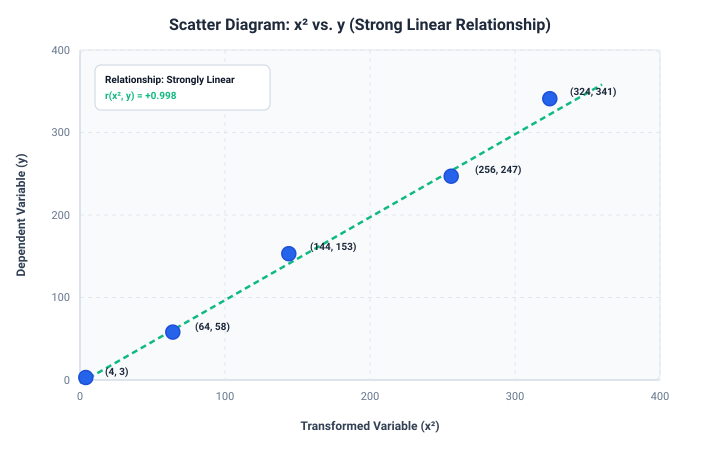

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(df["x2"], df["y"], color="#2563eb", s=90, zorder=3, edgecolors="#1d4ed8", linewidths=1.5)

# Annotate points
for _, row in df.iterrows():
    ax.annotate(f"({row['x2']}, {row['y']})", (row["x2"], row["y"]), textcoords="offset points", xytext=(12, -2), fontsize=9, weight="bold")

# Linear regression fit
m, b = np.polyfit(df["x2"], df["y"], 1)
x_vals = np.linspace(0, 360, 100)
ax.plot(x_vals, m * x_vals + b, color="#10b981", linestyle="--", linewidth=2, label=f"Linear fit: y = {b:.2f} + {m:.3f}x²")

ax.set_title("Scatter Diagram: x² vs. y (Strong Linear Relationship)", fontsize=12, pad=10, fontweight="bold")
ax.set_xlabel("Transformed Variable (x²)", fontsize=11)
ax.set_ylabel("Dependent Variable (y)", fontsize=11)
ax.set_xlim(0, 400)
ax.set_ylim(0, 400)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Description of Relationship between $x^2$ and $y$:**
- The relationship between $x^2$ and $y$ is **exceptionally strong, positive, and linear**.
- All five data points lie almost perfectly along a single straight line passing near the origin.

## e. Compute the correlation coefficient between x2 and y.

### Step-by-Step Calculation Table

Let $z = x^2$:
- $\bar{z} = \frac{64 + 256 + 144 + 4 + 324}{5} = \frac{792}{5} = 158.4$
- $\bar{y} = 160.4$

| Point | $x^2$ ($z$) | $y$ | $z - \bar{z}$ | $(z - \bar{z})^2$ | $y - \bar{y}$ | $(y - \bar{y})^2$ | $(z - \bar{z})(y - \bar{y})$ |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | 64 | 58 | -94.4 | 8911.36 | -102.4 | 10485.76 | 9666.56 |
| 2 | 256 | 247 | 97.6 | 9525.76 | 86.6 | 7499.56 | 8452.16 |
| 3 | 144 | 153 | -14.4 | 207.36 | -7.4 | 54.76 | 106.56 |
| 4 | 4 | 3 | -154.4 | 23839.36 | -157.4 | 24774.76 | 24302.56 |
| 5 | 324 | 341 | 165.6 | 27423.36 | 180.6 | 32616.36 | 29907.36 |
| **Total ($\Sigma$)** | **792** | **802** | **0.0** | **69907.20** | **0.0** | **75431.20** | **72435.20** |

### Formula & Calculation
$$SS_{zz} = 69,907.20, \quad SS_{yy} = 75,431.20, \quad SS_{zy} = 72,435.20$$

$$r_{x^2, y} = \frac{SS_{zy}}{\sqrt{SS_{zz} \cdot SS_{yy}}} = \frac{72435.20}{\sqrt{69907.20 \times 75431.20}} = \frac{72435.20}{\sqrt{5273189912.64}} = \frac{72435.20}{72616.733} \approx \mathbf{0.9975} \approx \mathbf{0.998}$$

*Conclusion:* There is an **almost perfect positive linear correlation** ($r \approx 0.998$, $r^2 \approx 0.995$).

In [6]:
r_x2y = df["x2"].corr(df["y"])
print(f"Correlation coefficient r(x^2, y) = {r_x2y:.4f}")
print(f"Coefficient of determination r^2 = {r_x2y**2:.4f}")

Correlation coefficient r(x^2, y) = 0.9975
Coefficient of determination r^2 = 0.9950


## f. Compare the relationships between x and y, and x2 and y.

| Feature | $x$ and $y$ | $x^2$ and $y$ |
| :--- | :--- | :--- |
| **Shape of plot** | U-shaped, parabolic curve | Straight diagonal line |
| **Type of relationship** | Strongly **nonlinear** (quadratic) | Strongly **linear** |
| **Linear correlation ($r$)** | **$r = 0.298$** (weak linear association) | **$r = 0.998$** (nearly perfect linear association) |
| **Explained variance ($r^2$)** | **$8.9\%$** ($0.2975^2 = 0.0885$) | **$99.5\%$** ($0.9975^2 = 0.9950$) |

- In the original scale ($x$ vs. $y$), positive and negative values cancel each other out linearly, giving an artificially low Pearson correlation of $0.298$.
- Squaring $x$ eliminates the sign effect and straightens the parabolic curve into a nearly straight line, revealing the true underlying functional relationship.

## g. Interpret your results.

1. **Pearson's $r$ only detects linear relationships:** A correlation near zero (or weak like $0.298$) does **not** mean there is no relationship—it only means there is no *linear* relationship. Two variables can have an exact mathematical relationship (like $y \approx x^2$) and still have a low linear correlation.
2. **Always plot the data first:** A scatter diagram is essential to inspect the functional shape before relying solely on summary statistics like the correlation coefficient.
3. **Power of Variable Transformation:** When data exhibits a curvilinear trend, transforming variables (e.g., polynomial transformations like $x^2$, or logarithmic transformations) can linearize the relationship, allowing ordinary linear regression to fit the data with extreme accuracy ($r^2 = 99.5\%$).